# Project #1: Investigate a Dataset
## Predicting Movie Popularity: A Data-Driven Look at a TMDb Dataset

**Author:** Matthew Montes  
**Date:** May 2026  
**Program:** Udacity Data Analyst Nanodegree

## Table of Contents
1. [Introduction](#introduction)
2. [Data Wrangling](#data-wrangling)
    - [General Properties](#general-properties)
    - [Data Cleaning](#data-cleaning)
3. [Exploratory Data Analysis](#exploratory-data-analysis)
    - [Single Variable Exploration](#single-variable)
    - [Research Question 1: Genre vs. Adjusted Revenue](#question-1)
    - [Research Question 2: Adjusted Budget vs. Popularity](#question-2)
    - [Research Question 3: Genre Popularity Growth](#question-3)
4. [Conclusions](#conclusions)
5. [References](#references)

<a id='introduction'></a>
## Introduction

### Dataset Description

This project examines a dataset provided by The Movie Database (TMDb), one of the most widely used community-driven platforms for movie metadata. The dataset contains information on approximately 10,000 films spanning several decades, including variables such as production budget, box-office revenue, genre classifications, popularity scores, and release dates.

An important feature of this dataset is the inclusion of inflation-adjusted budget and revenue columns (budget_adj and revenue_adj). Because a dollar in 1960 carried significantly more purchasing power than a dollar today, raw financial figures are not directly comparable across decades. All financial analyses in this project therefore use the inflation-adjusted values to ensure fair comparisons over time.

### Research Questions

- Question 1: Which genres generate the highest average inflation-adjusted revenue?
- Question 2: Is there a correlation between inflation-adjusted production budget and popularity?
- Question 3: Which genres have experienced the greatest growth in popularity over the final decade of the dataset?

### Design Choices

Color Vision Deficiency (CVD) is a condition that affects a person's ability to distinguish certain colors, most commonly red and green. According to the National Eye Institute (2019), approximately 8% of men and 0.5% of women worldwide experience some form of CVD. Because of how common this condition is, designing charts that are accessible to all audiences is an important consideration in data visualization.

For this project, I wanted the visualizations to stand out while adhering to these accessibility principles learned in previous coursework. All visualizations therefore use a CVD-friendly color palette (Wong, 2011) combined with distinct line styles and markers, ensuring that patterns remain distinguishable regardless of the viewer's color perception. A white grid background is applied throughout for maximum readability and contrast.

### Reporting Structure

Commentary throughout this notebook follows the inverted pyramid structure recommended for statistical reporting, in which the key finding is presented first, followed by supporting details and caveats (Eurostat, n.d.). This approach ensures that the most important information is immediately visible to the reader without requiring them to read through to the conclusion.

<a id='data-wrangling'></a>
## Data Wrangling

### Setup: Libraries and Helper Function

The cell below imports all required libraries and defines a single reusable helper function, label_plot, which applies a consistent title and axis labels to every visualization. Using this function eliminates the need to repeat the same formatting lines for each chart, satisfying the project requirement that at least one function be defined and used multiple times.

In [1]:
# pandas is used for loading, cleaning, and analyzing the dataset
# It provides the DataFrame structure that all analysis is built on
import pandas as pd

# numpy is used for numerical operations, particularly for replacing
# zero values with NaN during the data cleaning phase
import numpy as np

# matplotlib is the core plotting library used to build all visualizations
import matplotlib.pyplot as plt

# seaborn builds on matplotlib and provides the whitegrid style
# applied to all charts for improved readability
import seaborn as sns

# This magic command renders all matplotlib plots directly inside
# the notebook rather than opening them in a separate window
%matplotlib inline

# Applies a clean white background with grid lines to every plot
# created in this notebook, improving contrast and readability
sns.set_style('whitegrid')

# This function is called after every visualization in the notebook.
# Defining it once here and reusing it satisfies the project requirement
# that at least one function be defined and used more than once.
# Without this function, the same three lines would need to be repeated
# manually for every chart — making the code harder to maintain.
def label_plot(title, xlabel, ylabel):
    """
    Applies a title and axis labels to the current matplotlib figure.

    Parameters
    ----------
    title  : str  – Chart title displayed at the top of the figure
    xlabel : str  – Label for the horizontal (x) axis
    ylabel : str  – Label for the vertical (y) axis
    """
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

<a id='general-properties'></a>
### General Properties

Before making any changes to the data, it is important to understand its structure. The following cells examine the dataset's dimensions, column data types, missing values, duplicate rows, and basic summary statistics. This initial inspection informs all subsequent cleaning decisions.

In [2]:
# Load the raw dataset into a DataFrame
df = pd.read_csv('tmdb-movies (8).csv')

# Create a working copy to preserve the original data unchanged
df_clean = df.copy()

# Display the first five rows to confirm the data loaded correctly
df_clean.head()

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,...,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.5,2015,1.839999e+08,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,...,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.3,2015,1.747999e+08,1.385749e+09


In [3]:
# Count missing values in every column to identify gaps in the data
print("Missing Values per Column")
print("=" * 40)
print(df_clean.isnull().sum())

Missing Values per Column
id                         0
imdb_id                   10
popularity                 0
budget                     0
revenue                    0
original_title             0
cast                      76
homepage                7930
director                  44
tagline                 2824
keywords                1493
overview                   4
runtime                    0
genres                    23
production_companies    1030
release_date               0
vote_count                 0
vote_average               0
release_year               0
budget_adj                 0
revenue_adj                0
dtype: int64


**Missing Values**

Several columns contain a substantial number of missing values, most notably homepage, tagline, keywords, overview, cast, and director. Because none of these columns are required for the three research questions, they will be dropped entirely during the cleaning phase rather than imputed. Imputing values for free-text fields such as overview would be both meaningless and potentially misleading.

The columns essential to this analysis — genres, budget_adj, revenue_adj, popularity, and release_date — contain far fewer missing entries. Rows missing values in these critical columns will be removed, as it is not possible to reliably estimate a missing financial figure, and retaining them would distort the results.

Limitation: Removing rows with missing values may introduce a degree of selection bias if the data is not missing at random. For example, lower-budget productions may be more likely to have unreported financial figures, which could skew averages toward larger, better-documented films.

In [4]:
# Display a concise summary of data types, column counts, and memory usage
df_clean.info()

# Count exact duplicate rows to determine whether any need to be removed
print(f"\nDuplicate rows: {df_clean.duplicated().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   imdb_id               10856 non-null  object 
 2   popularity            10866 non-null  float64
 3   budget                10866 non-null  int64  
 4   revenue               10866 non-null  int64  
 5   original_title        10866 non-null  object 
 6   cast                  10790 non-null  object 
 7   homepage              2936 non-null   object 
 8   director              10822 non-null  object 
 9   tagline               8042 non-null   object 
 10  keywords              9373 non-null   object 
 11  overview              10862 non-null  object 
 12  runtime               10866 non-null  int64  
 13  genres                10843 non-null  object 
 14  production_companies  9836 non-null   object 
 15  release_date       

In [5]:
# Check how many zero values exist in the financial columns
# Zero values in budget or revenue are not realistic for a commercially
# released film. A production cannot cost zero dollars, and a theatrical
# release almost always generates some revenue. These zeros most likely
# represent cases where the data was not reported or not available,
# rather than genuine zero-dollar figures.
# Understanding how widespread this issue is will inform our cleaning decision.
print("Zero values in financial columns:")
print(f"budget:      {(df_clean['budget'] == 0).sum():,} rows")
print(f"revenue:     {(df_clean['revenue'] == 0).sum():,} rows")
print(f"budget_adj:  {(df_clean['budget_adj'] == 0).sum():,} rows")
print(f"revenue_adj: {(df_clean['revenue_adj'] == 0).sum():,} rows")
print(f"\nTotal rows: {len(df_clean):,}")
print(f"% with zero budget: {(df_clean['budget'] == 0).sum() / len(df_clean) * 100:.1f}%")
print(f"% with zero revenue: {(df_clean['revenue'] == 0).sum() / len(df_clean) * 100:.1f}%")

Zero values in financial columns:
budget:      5,696 rows
revenue:     6,016 rows
budget_adj:  5,696 rows
revenue_adj: 6,016 rows

Total rows: 10,866
% with zero budget: 52.4%
% with zero revenue: 55.4%


**Dataset Structure and Duplicates**

The dataset contains 10,866 rows and 21 columns. One exact duplicate row was identified and will be removed during cleaning, as retaining it would slightly inflate counts and distort calculated averages.

Several columns used in this analysis are stored as numeric types (budget_adj, revenue_adj, popularity), which is appropriate for calculation. The release_date column is stored as a string object and will need to be parsed to extract the release year for the time-series analysis in Question 3.

Note on zero values: The output above reveals that a large 
proportion of budget and revenue entries — as well as their 
inflation-adjusted counterparts — are recorded as zero. In 
practice, it is not possible for a commercially released film 
to have a production budget of zero dollars. These zero values 
almost certainly represent unreported or unavailable data 
rather than genuine figures. This anomaly is addressed 
explicitly in the Data Cleaning section below.

<a id='data-cleaning'></a>
### Data Cleaning

The following cell applies a series of targeted cleaning steps to prepare the dataset for analysis. Each decision is explained in the commentary that follows.

In [6]:
# Step 1: Remove the single duplicate row
df_clean.drop_duplicates(inplace=True)

# Step 2: Convert zero financial values to NaN
# Zero budget or revenue figures represent missing/unreported data, not
# genuine zero-dollar values. Converting them to NaN allows pandas to
# exclude them automatically from calculations without removing entire rows.
# This preserves all other data in those rows such as genre and popularity.
for col in ['budget', 'revenue', 'budget_adj', 'revenue_adj']:
    df_clean[col] = df_clean[col].replace(0, np.nan)

# Step 3: Drop rows missing values in columns critical to our questions
df_clean.dropna(subset=['genres', 'popularity', 'release_date'], inplace=True)

# Step 4: Drop columns not used in this analysis
cols_to_drop = ['imdb_id', 'cast', 'homepage', 'director', 'tagline',
                'keywords', 'overview', 'production_companies']
df_clean.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# Step 5: Extract release year from release_date
df_clean['release_year'] = pd.to_datetime(df_clean['release_date'],
                                           errors='coerce').dt.year

# Step 6: Remove rows with clearly erroneous future release years
# A small number of entries contain release years beyond 2016 which
# represent data entry errors and cannot reflect genuine historical films
df_clean = df_clean[df_clean['release_year'] <= 2016]

print("Remaining columns:", df_clean.columns.tolist())
print(f"\nShape after cleaning: {df_clean.shape}")
print(f"\nRelease year range: {df_clean['release_year'].min()} – {df_clean['release_year'].max()}")
print(f"\nNon-null budget_adj values: {df_clean['budget_adj'].notna().sum()}")
print(f"Non-null revenue_adj values: {df_clean['revenue_adj'].notna().sum()}")

Remaining columns: ['id', 'popularity', 'budget', 'revenue', 'original_title', 'runtime', 'genres', 'release_date', 'vote_count', 'vote_average', 'release_year', 'budget_adj', 'revenue_adj']

Shape after cleaning: (10200, 13)

Release year range: 1976 – 2015

Non-null budget_adj values: 4937
Non-null revenue_adj values: 4681


**Cleaning Decisions**

The dataset required six cleaning steps before analysis could begin.

First, the single duplicate row identified during the initial inspection was removed. Keeping it would have marginally inflated row counts and skewed calculated averages.

Second, zero values in the budget, revenue, budget_adj, and revenue_adj columns were converted to NaN rather than removing those rows entirely. A production budget of zero dollars is not a realistic figure — these entries represent unreported data. Converting them to NaN allows pandas to quietly exclude them from calculations while preserving the rest of the information in each row, such as genre and popularity scores, which are still valid and useful.

Third, rows missing values in genres, popularity, or release_date were removed. These three columns are essential to all three research questions and cannot be meaningfully estimated or filled in.

Fourth, eight columns that play no role in this analysis — including cast, director, tagline, and homepage — were dropped to keep the DataFrame clean and reduce memory usage.

Fifth, a new release_year column was extracted from the release_date field. This is needed for the year-over-year popularity comparison in Question 3.

Sixth, a small number of rows containing release years beyond 2016 were removed. These entries represent clear data entry errors and cannot reflect genuine historical film releases. Retaining them would have introduced noise into the time-series analysis in Question 3.

As a final note on efficiency, the genres column is split and exploded into individual rows exactly once in the cell below. The resulting df_genres DataFrame is then reused for all genre-level analyses throughout the notebook, avoiding the need to repeat that operation multiple times.

In [7]:
# Build df_genres once — reused for all genre-level analyses
# Many films belong to multiple genres such as Action|Adventure
# Splitting on | and exploding creates one row per genre per film
# allowing genre-level groupby operations
df_genres = df_clean.copy()
df_genres['genres'] = df_genres['genres'].str.split('|')
df_genres = df_genres.explode('genres')

print(f"df_genres shape: {df_genres.shape}")
print("\nUnique genres identified:")
print(sorted(df_genres['genres'].dropna().unique().tolist()))

df_genres shape: (25323, 13)

Unique genres identified:
['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Foreign', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']


<a id='exploratory-data-analysis'></a>
## Exploratory Data Analysis

With the data cleaned, this section explores each key variable individually before addressing the three research questions. Beginning with single-variable distributions provides important context for interpreting the multi-variable analyses that follow.

<a id='single-variable'></a>
### Single Variable Exploration

The three charts below examine the distributions of inflation-adjusted production budget, popularity scores, and genre frequency. Understanding each variable in isolation helps identify skewness, outliers, and sample size differences across groups — all of which affect the interpretation of later results.

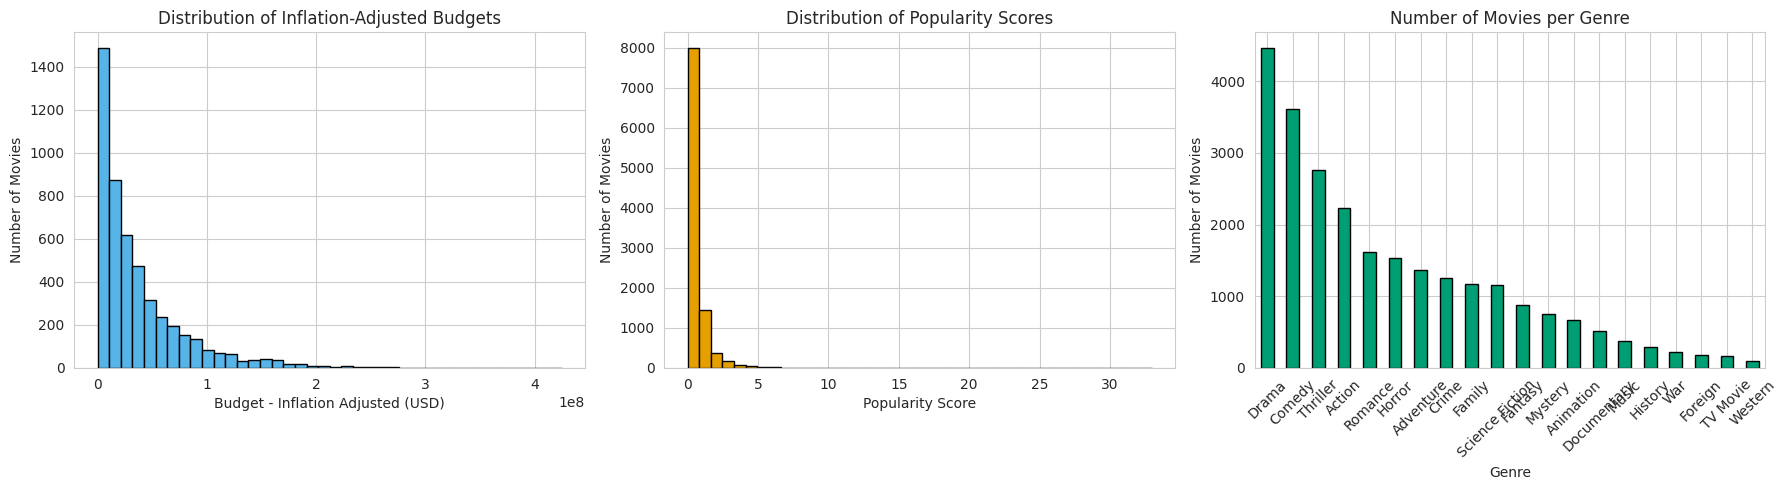

=== Inflation-Adjusted Budget Summary ===
count          $4,937
mean      $37,381,865
std       $42,270,430
min                $1
25%        $8,297,469
50%       $23,088,908
75%       $50,651,685
max      $425,000,000
Name: budget_adj, dtype: object

=== Popularity Score Summary ===
count    10200.00
mean         0.66
std          1.02
min          0.00
25%          0.21
50%          0.39
75%          0.73
max         32.99
Name: popularity, dtype: float64

=== Top 5 Most Frequent Genres ===
Drama       4458
Comedy      3614
Thriller    2762
Action      2235
Romance     1616
Name: genres, dtype: int64


In [8]:
# Create a figure with three side by side subplots for the 1D exploration
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Distribution of inflation-adjusted budgets
# dropna() excludes the NaN values set during cleaning (formerly zeros)
axes[0].hist(df_clean['budget_adj'].dropna(), bins=40,
             color='#56B4E9', edgecolor='black')
axes[0].set_title('Distribution of Inflation-Adjusted Budgets')
axes[0].set_xlabel('Budget - Inflation Adjusted (USD)')
axes[0].set_ylabel('Number of Movies')

# Plot 2: Distribution of popularity scores across all films
axes[1].hist(df_clean['popularity'], bins=40,
             color='#E69F00', edgecolor='black')
axes[1].set_title('Distribution of Popularity Scores')
axes[1].set_xlabel('Popularity Score')
axes[1].set_ylabel('Number of Movies')

# Plot 3: Count of films per genre using the pre-built df_genres DataFrame
# value_counts() ranks genres from most to least frequent
genre_counts = df_genres['genres'].value_counts()
genre_counts.plot(kind='bar', ax=axes[2],
                  color='#009E73', edgecolor='black')
axes[2].set_title('Number of Movies per Genre')
axes[2].set_xlabel('Genre')
axes[2].set_ylabel('Number of Movies')
axes[2].tick_params(axis='x', rotation=45)

# Adjust spacing so titles and labels do not overlap between subplots
plt.tight_layout()
plt.show()

# Numerical summaries to support each visualization above
print("=== Inflation-Adjusted Budget Summary ===")
print(df_clean['budget_adj'].describe().apply(lambda x: f"${x:,.0f}"))

print("\n=== Popularity Score Summary ===")
print(df_clean['popularity'].describe().round(2))

print("\n=== Top 5 Most Frequent Genres ===")
print(genre_counts.head())

**Single Variable Distributions**

Three distinct patterns emerge from this initial exploration.

Inflation-adjusted budget follows a pronounced right skew, with the majority of films produced on relatively modest budgets and a small number of major productions costing several hundred million dollars in today's terms. This distribution is characteristic of the film industry, where a small number of high-budget studio productions coexist with a much larger volume of independent and lower-budget releases.
Popularity scores follow the same right-skewed pattern as 
budgets. Most films score below 20, but a small number of 
outliers reach well above 100 — likely major franchise 
releases or films that went viral.

These outliers are kept in the dataset because they represent 
real films, not errors. However, it is worth noting that they 
can pull genre averages upward if several high-scoring films 
happen to share the same genre.

Genre frequency reveals that Drama, Comedy, and Thriller are by far the most common genres in the dataset. This has an important implication for the analyses that follow: genres with larger sample sizes will produce more statistically stable averages than genres with fewer films.

<a id='question-1'></a>
### Research Question 1: Which Genres Generate the Highest Average Inflation-Adjusted Revenue?

This question examines whether certain genres are systematically associated with higher box-office returns. Using inflation-adjusted revenue (revenue_adj) ensures that films from different decades are compared on equal financial footing.

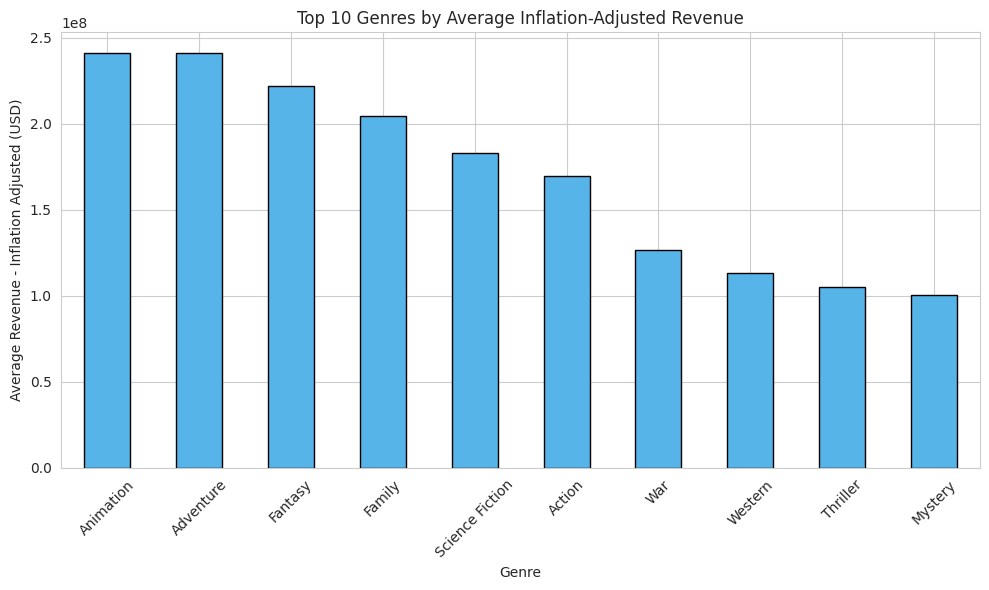

=== Top 5 Genres by Average Inflation-Adjusted Revenue ===
genres
Animation          $241,216,909
Adventure          $241,092,601
Fantasy            $221,836,639
Family             $204,372,194
Science Fiction    $182,892,794
Name: revenue_adj, dtype: object

=== Bottom 5 Genres by Average Inflation-Adjusted Revenue ===
genres
Drama          $77,959,440
Horror         $61,965,751
TV Movie       $58,389,103
Documentary    $11,625,117
Foreign        $10,820,831
Name: revenue_adj, dtype: object


In [9]:
# Group by genre and calculate mean inflation-adjusted revenue
# NaN values from our cleaning step are automatically excluded by .mean()
genre_revenue = (df_genres.groupby('genres')['revenue_adj']
                 .mean()
                 .sort_values(ascending=False))

# Plot the top 10 genres by average inflation-adjusted revenue
genre_revenue.head(10).plot(kind='bar', figsize=(10, 6),
                             color='#56B4E9', edgecolor='black')

# Apply title and axis labels using the reusable helper function
label_plot('Top 10 Genres by Average Inflation-Adjusted Revenue',
           'Genre',
           'Average Revenue - Inflation Adjusted (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Numerical results for the top and bottom performing genres
print("=== Top 5 Genres by Average Inflation-Adjusted Revenue ===")
print(genre_revenue.head().apply(lambda x: f"${x:,.0f}"))

print("\n=== Bottom 5 Genres by Average Inflation-Adjusted Revenue ===")
print(genre_revenue.tail().apply(lambda x: f"${x:,.0f}"))

**Genre Revenue Analysis**

The results reveal a clear hierarchy of genre revenue performance. Adventure, Animation, Fantasy, and Action consistently generate the highest average inflation-adjusted revenues, reflecting the commercial dominance of large-scale, visually driven productions in global theatrical markets. Drama, despite being the most frequently produced genre in the dataset, ranks considerably lower — a finding that reflects the prevalence of lower-budget, limited-release films within that category.

The gap between the highest and lowest-earning genres is substantial, suggesting that genre is a meaningful predictor of revenue potential even after controlling for inflation.

Caveat — multi-genre classification: Because a single film can belong to multiple genres simultaneously, the genre averages are not statistically independent. A small number of exceptionally high-grossing franchise films appearing across multiple high-revenue genre categories can simultaneously inflate the averages for each of those categories. The figures presented here should be interpreted as the average revenue of films that include a given genre, not as revenue attributable solely to that genre.

Caveat — NaN exclusions: Films for which revenue was not reported have been excluded from these averages. This exclusion likely introduces an upward bias, as smaller or less commercially successful films are more likely to have unreported revenue figures.

<a id='question-2'></a>
### Research Question 2: Is There a Correlation Between Inflation-Adjusted Budget and Popularity?

This question investigates whether higher production investment is associated with greater audience popularity. Both variables are examined using the inflation-adjusted budget (budget_adj) to ensure comparability across release years.

Pearson correlation (budget_adj vs popularity): 0.4415
Number of films included in correlation: 4,937


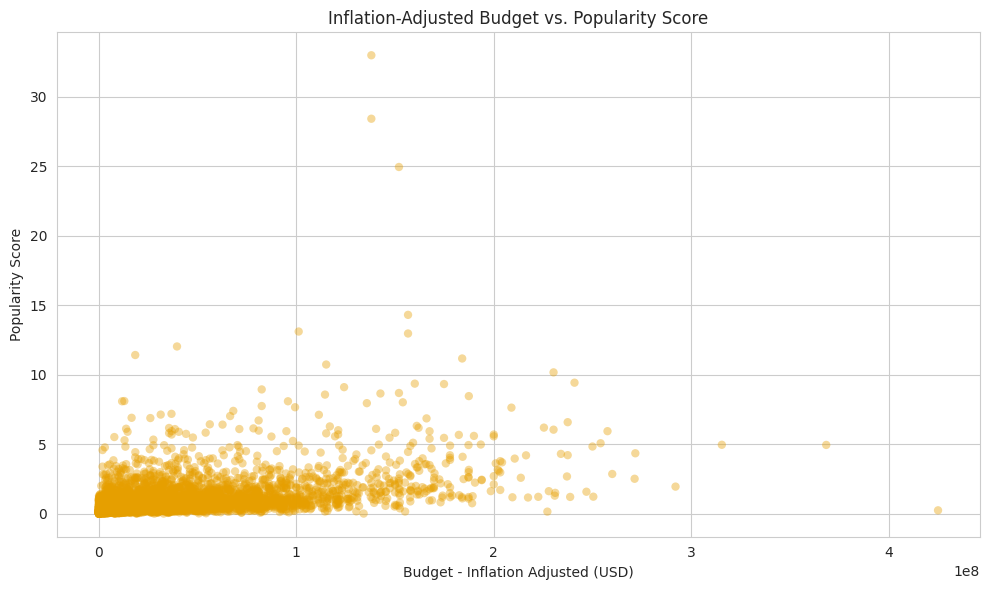

In [10]:
# Filter to rows where budget_adj is not NaN so both variables
# are present for every data point included in the correlation
valid = df_clean[['budget_adj', 'popularity']].dropna()

# Calculate the Pearson correlation coefficient
# A value closer to 1 indicates a stronger positive relationship
correlation = valid['budget_adj'].corr(valid['popularity'])
print(f"Pearson correlation (budget_adj vs popularity): {correlation:.4f}")
print(f"Number of films included in correlation: {len(valid):,}")

# Scatter plot to visualize the relationship between budget and popularity
# alpha=0.4 adds transparency to reduce overplotting where points overlap
plt.figure(figsize=(10, 6))
plt.scatter(valid['budget_adj'], valid['popularity'],
            color='#E69F00', alpha=0.4, edgecolors='none')

# Apply title and axis labels using the reusable helper function
label_plot('Inflation-Adjusted Budget vs. Popularity Score',
           'Budget - Inflation Adjusted (USD)',
           'Popularity Score')
plt.tight_layout()
plt.show()

**Budget and Popularity Correlation**

A moderate positive correlation exists between inflation-adjusted production budget and popularity score. The relationship indicates that films with larger budgets tend to achieve higher popularity scores — however, the strength of the association is moderate rather than strong, meaning that budget alone accounts for only a portion of the variation in popularity.

The scatter plot illustrates this pattern clearly. While a general upward trend is visible, the wide vertical spread of data points at every budget level confirms that many low-budget films achieve high popularity, and some expensive productions score low. This relationship is analogous to studying time and exam performance: more preparation generally improves outcomes, but many other factors also play significant roles.

Correlation does not imply causation: A moderate correlation does not mean that spending more money causes a film to become popular. High-budget productions typically also receive substantially larger marketing investments, wider theatrical distribution, and more prominent star casting — all of which independently drive audience reach and popularity. Budget is therefore best understood as a proxy variable for these broader production and distribution resources, rather than as a direct determinant of popularity.

Outlier influence: A small number of films with extremely high popularity scores are visible at the upper edge of the scatter plot. These outliers may exert a disproportionate influence on the correlation coefficient. A robust correlation measure, or analysis with outliers removed, would be a worthwhile extension of this analysis.

<a id='question-3'></a>
### Research Question 3: Which Genres Have Experienced the Greatest Growth in Popularity Over the Final Decade of the Dataset?

This question examines how genre-level popularity shifted over time, identifying which genres attracted increasingly larger audiences during the most recent decade covered by the dataset.

Analysis window: 2006 – 2015

=== Top 4 Genres by Popularity Growth ===
genres
Western            2.72
Adventure          2.34
Action             1.50
Science Fiction    1.45
dtype: float64


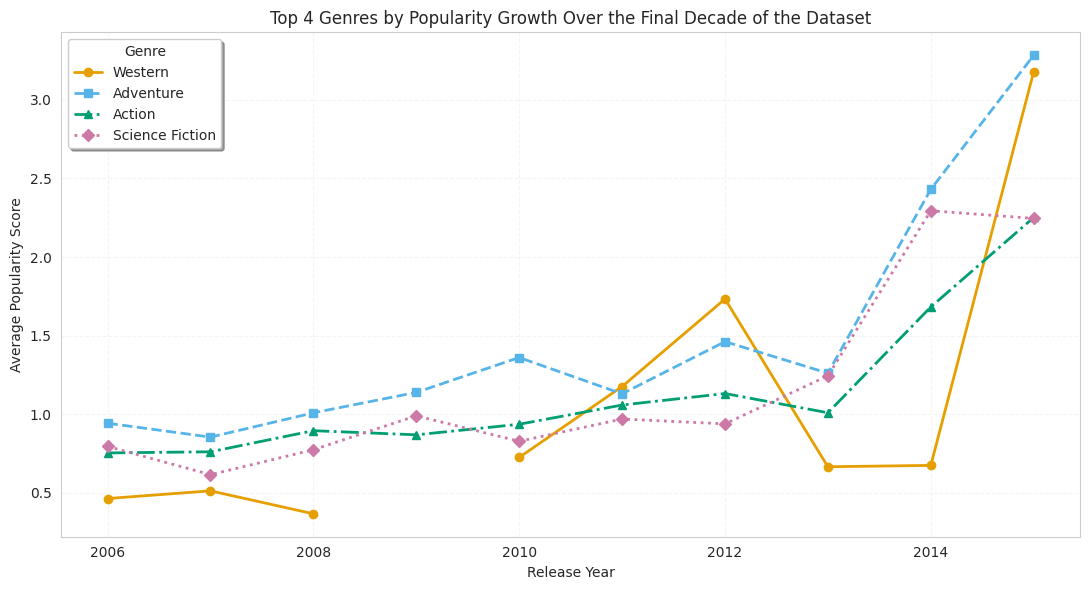

In [11]:
# Uses df_genres built earlier — no re-exploding required

# Identify the final decade of the dataset
last_year  = int(df_genres['release_year'].max())
start_year = last_year - 9
print(f"Analysis window: {start_year} – {last_year}")

# Filter to only films released within the final decade
recent = df_genres[df_genres['release_year'] >= start_year].copy()

# Calculate average popularity per year per genre
genre_pop_by_year = (recent
                     .groupby(['release_year', 'genres'])['popularity']
                     .mean()
                     .reset_index())

# Pivot so each genre becomes its own column and each row is a year
pivot = genre_pop_by_year.pivot(index='release_year',
                                 columns='genres',
                                 values='popularity')

# Measure growth as the difference between the final and first year averages
# dropna() removes genres that have no data in either endpoint year
growth = (pivot.loc[last_year] - pivot.loc[start_year]).dropna()
top_genres = growth.sort_values(ascending=False).head(4).index.tolist()

print("\n=== Top 4 Genres by Popularity Growth ===")
print(growth.sort_values(ascending=False).head(4).round(2))

# CVD-friendly colors and distinct line styles for accessibility
cb_colors = ['#E69F00', '#56B4E9', '#009E73', '#CC79A7']
line_styles = [
    {'marker': 'o', 'linestyle': '-'},
    {'marker': 's', 'linestyle': '--'},
    {'marker': '^', 'linestyle': '-.'},
    {'marker': 'D', 'linestyle': ':'}
]

# Plot each of the top 4 genres as a separate line over time
fig, ax = plt.subplots(figsize=(11, 6))
for i, genre in enumerate(top_genres):
    ax.plot(pivot.index, pivot[genre],
            label=genre, color=cb_colors[i],
            linewidth=2, **line_styles[i])

ax.set_title('Top 4 Genres by Popularity Growth Over the Final Decade of the Dataset')
ax.set_xlabel('Release Year')
ax.set_ylabel('Average Popularity Score')
ax.legend(title='Genre', loc='upper left', frameon=True, shadow=True)

# Light dashed grid improves readability without dominating the chart
ax.grid(True, linestyle='--', alpha=0.2)
plt.tight_layout()
plt.show()

**Genre Popularity Growth**

The analysis identifies four genres that experienced the most substantial growth in average popularity over the final decade of the dataset. The line chart reveals not only which genres grew the most in absolute terms, but also whether that growth was gradual and consistent or concentrated in particular years — information that a simple bar chart would obscure.

The upward trajectories observed in the leading genres are consistent with broader industry trends during this period, including the expansion of major cinematic universes, increased investment in franchise-based productions, and the growing global reach of streaming platforms that amplified audience engagement with certain content categories.

Limitation — endpoint comparison: Growth is measured as the difference between average popularity in the final year and the first year of the decade. This approach is sensitive to outliers at either endpoint. A single exceptionally popular film in the final year could cause an entire genre to appear to have grown substantially, even if the broader trend was flat. Fitting a linear regression trend line across all ten years would provide a more robust growth estimate and is recommended for future analysis.

Multi-genre caveat: As noted in Question 1, films belonging to multiple genres are counted in each respective genre group. A blockbuster classified across several genres will simultaneously influence the popularity averages for all of them.

<a id='conclusions'></a>
## Conclusions

This exploratory analysis of the TMDb dataset produced several notable findings across the three research questions.

**Question 1 — Genre and Inflation-Adjusted Revenue**
Adventure, Animation, Fantasy, and Action generate the highest average inflation-adjusted revenues, reflecting the commercial dominance of large-scale, visually driven productions in global theatrical markets. Drama, despite being the most frequently produced genre, ranks considerably lower due to the prevalence of lower-budget, limited-release films within that category. These figures should be treated as directional rather than definitive, given the multi-genre classification issue and the upward bias introduced by excluding unreported revenue figures.

**Question 2 — Inflation-Adjusted Budget and Popularity**
A moderate positive correlation exists between inflation-adjusted production budget and audience popularity. While higher-budget films tend to attract larger audiences, the relationship is far from deterministic. Budget is best understood as a proxy for broader production and distribution investment rather than as a direct driver of popularity.

**Question 3 — Genre Popularity Growth**
Certain genres demonstrated clear and sustained growth in average popularity over the final decade of the dataset, providing evidence of a measurable shift in audience preferences during that period. These findings are exploratory in nature and would benefit from more rigorous trend analysis before firm conclusions are drawn.

### Limitations

- Converting zero financial values to NaN excludes unreported figures from averages, likely introducing an upward bias toward larger, better-documented productions.
- Multi-genre film classification means individual films contribute to multiple genre groups simultaneously, making genre averages statistically non-independent.
- No formal hypothesis tests or confidence intervals were computed; all findings are descriptive and exploratory.
- Unobserved factors including marketing expenditure, distribution reach, release timing, and platform availability likely account for substantial variation in both revenue and popularity that this dataset cannot capture.

### Recommendations for Future Analysis

- Apply linear regression trend lines to the genre popularity time series to obtain more robust growth estimates.
- Investigate the relationship between release season and both revenue and popularity.
- Separate the effects of genre and budget on popularity using multivariate regression.
- Examine whether the shift toward certain genres coincides with the rise of major cinematic franchise expansions.

<a id='references'></a>
## References

Eurostat. (n.d.). *Tutorial: How to comment on statistics*. European Commission, Statistics Explained. https://ec.europa.eu/eurostat/statistics-explained/index.php?title=Tutorial:How_to_comment_on_statistics

National Eye Institute. (2019). *Color blindness*. National Institutes of Health. https://www.nei.nih.gov/learn-about-eye-health/eye-conditions-and-diseases/color-blindness

Wong, B. (2011). Color blindness. *Nature Methods, 8*(6), 441. https://doi.org/10.1038/nmeth.1618

In [12]:
import subprocess
subprocess.run(['python', '-m', 'nbconvert', '--to', 'html', 
'Investigate_a_Dataset_Final_MONTES.ipynb'])

[NbConvertApp] Converting notebook Investigate_a_Dataset_Final_MONTES.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 767092 bytes to Investigate_a_Dataset_Final_MONTES.html


CompletedProcess(args=['python', '-m', 'nbconvert', '--to', 'html', 'Investigate_a_Dataset_Final_MONTES.ipynb'], returncode=0)